Tên: Lê Văn Huy | MSSV: 070206007733


In [49]:
import matplotlib.pyplot as plt #thư viện dùng để vẽ biểu đồ
import numpy as np #tính toán, xử lý ma trận
from sklearn import datasets, metrics #dataset chứa dữ liệu mẫu còn metrics chứa hàm đánh giá mô hình
from sklearn.linear_model import LogisticRegression #thuật toán logistic
from sklearn.model_selection import train_test_split #hàm chia dữ liệu train, test
from sklearn.neighbors import KNeighborsClassifier #thuật toán phân loại KNN, hàng xóm gần nhất

In [50]:
dgt = datasets.load_digits() #lấy dữ liệu có sẵn từ thư viện
x_train, x_test, y_train, y_test, img_train, img_test = train_test_split(
    dgt.data, dgt.target, dgt.images, test_size=0.3, random_state=40
    #chia dữ liệu train và test theo tỉ lệ 70 và 30
)

In [51]:
knn_model = KNeighborsClassifier(n_neighbors=3) #khởi tạo thuật toán KNN với số hàng xóm là 3 (k = 3)
knn_model.fit(x_train, y_train) #bắt đầu huấn luyện
log_reg = LogisticRegression(max_iter=10000, random_state=40) #khởi tạo thuật toán logistic
                                                            #tăng số vòng lặp để dữ liệu hội tụ
log_reg.fit(x_train, y_train) #bắt đầu huấn luyện

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",40
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

In [52]:
predict_knn = knn_model.predict(x_test) #dùng mô hình KNN đã train để dự đoán trên tập test
predict_logreg = log_reg.predict(x_test)  #dùng mô hình logistic đã train để dự đoán trên tập test
print(f"Độ chính xác của KNN: {metrics.accuracy_score(y_test, predict_knn):.3f}") #in kết quả
print(f"Độ chính xác của Logistic Regression: {metrics.accuracy_score(y_test, predict_logreg):.3f}") #in kết quả

Độ chính xác của KNN: 0.983
Độ chính xác của Logistic Regression: 0.950


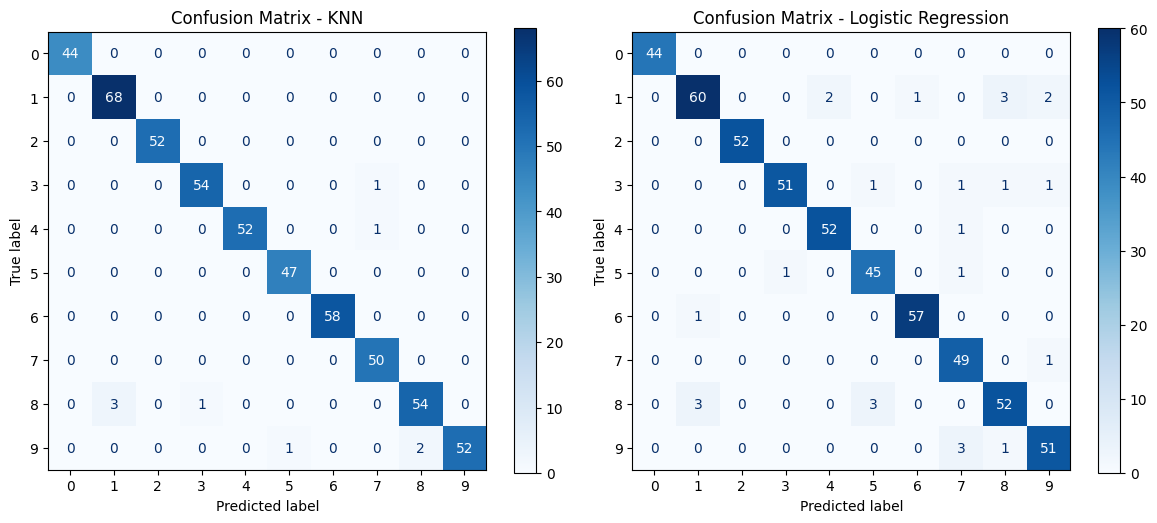

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))#tạo 1 khung có 2 cột để chứa biểu đổ
metrics.ConfusionMatrixDisplay.from_estimator(knn_model, x_test, y_test, ax=axes[0], cmap=plt.cm.Blues) 
                                                #vẽ ma trận nhầm lẫn cho KNN
axes[0].set_title("Confusion Matrix - KNN")#đặt tiêu đề

metrics.ConfusionMatrixDisplay.from_estimator(log_reg, x_test, y_test, ax=axes[1], cmap=plt.cm.Blues)
                                                #Vẽ ma trận nhầm lẫn cho Logistic
axes[1].set_title("Confusion Matrix - Logistic Regression") #đặt tiêu đề
plt.tight_layout()#tự động căn chỉnh
plt.show()

In [54]:
def plot_images(indices, title, max_show=5):
    num_images = min(len(indices), max_show) #nó lưu vào số ảnh hiển thị và phải < 5
    if num_images == 0:
        print(f"Không có mẫu: {title}") #dữ liệu trống
        return

    fig, axes = plt.subplots(1, num_images, figsize=(num_images * 2.5, 3))#tạo khung chứa ảnh
    if num_images == 1:
        axes = [axes] #đảm bảo nó luôn là 1 mảng dù chỉ có 1 ảnh

    for i, idx in enumerate(indices[:num_images]):
        axes[i].imshow(img_test[idx], cmap=plt.cm.gray_r, interpolation="nearest")#hiển thị ảnh với màu xám
        axes[i].set_title(f"Thực tế: {y_test[idx]}\nKNN: {predict_knn[idx]} | LR: {predict_logreg[idx]}") #ghi nhãn thật và kq dự đoán
        axes[i].axis("off") #tắt trục tọa độ để dễ nhìn hơn

    fig.suptitle(title, fontsize=14) #đặt tiêu đề chung
    plt.tight_layout()#tự động căn chỉnh
    plt.show()#in nó ra

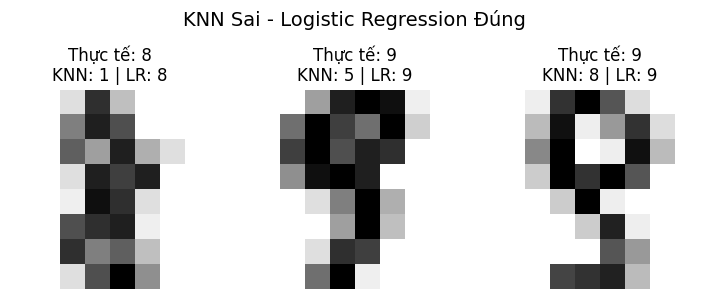

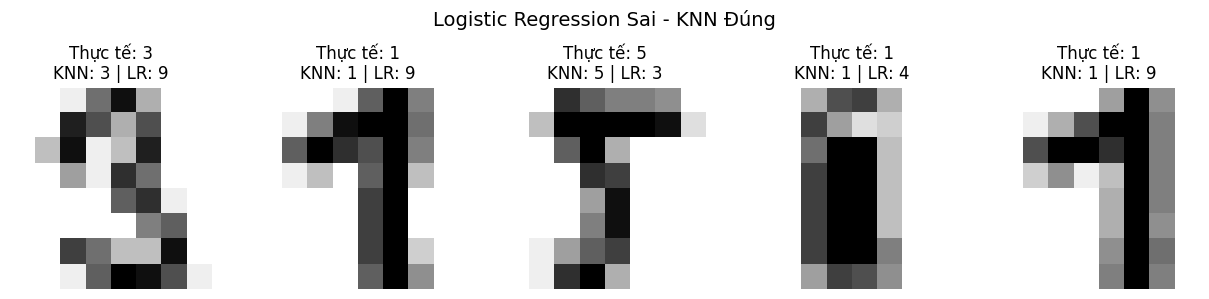

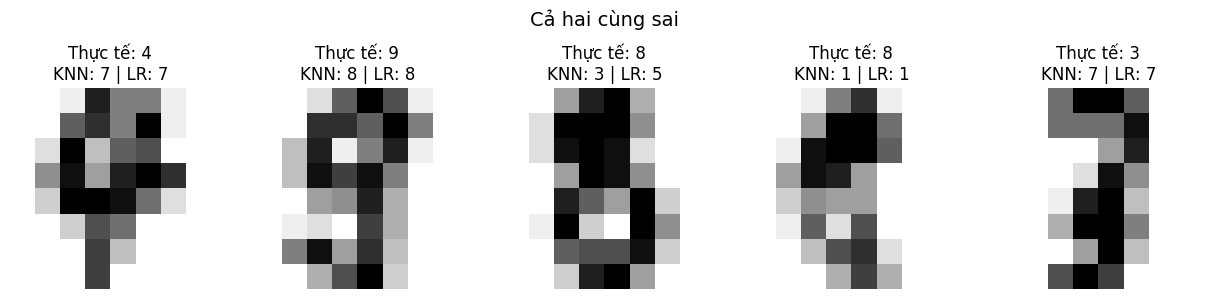

In [55]:
knn_wrong_lr_right = np.where((predict_knn != y_test) & (predict_logreg == y_test))[0]#lọc knn sai và log đúng
plot_images(knn_wrong_lr_right, "KNN Sai - Logistic Regression Đúng\n")#vẽ nó ra màn hình
lr_wrong_knn_right = np.where((predict_logreg != y_test) & (predict_knn == y_test))[0]#lọc knn đúng và log sai
plot_images(lr_wrong_knn_right, "Logistic Regression Sai - KNN Đúng\n")#vẽ nó ra màn hình
both_wrong = np.where((predict_knn != y_test) & (predict_logreg != y_test))[0]#lọc cả 2 cùng sai
plot_images(both_wrong, "Cả hai cùng sai\n")#vẽ nó ra màn hình